# Linear System Identification with Recursive Least Squares (RLS)

Notebook version of `linear_activities_RLS.py`.

Implementation of Activities 1, 2 and 3 from:
    https://helonayala.github.io/sysid/linear_activities_RLS.html

Built on top of the RLS example:
    https://helonayala.github.io/sysid/recursive_least_squares.html
and the regression / free-run helpers from A1 (linear_activities_BLS.py).

ARX model structure (shared with A1):

    y(k) = -a_1 y(k-1) - ... - a_na y(k-na)
           + b_1 u(k-1) + ... + b_nb u(k-nb)

    phi(k) = [ -y(k-1), ..., -y(k-na), u(k-1), ..., u(k-nb) ]^T
    y(k)   = phi(k)^T . theta

RLS update equations (forgetting-factor variant):

    K(k)   = P(k-1) phi(k) / (lambda + phi(k)^T P(k-1) phi(k))
    th(k)  = th(k-1) + K(k) e(k)
    P(k)   = (1/lambda) [ P(k-1) - K(k) phi(k)^T P(k-1) ]

with e(k) = y(k) - phi(k)^T th(k-1).

Activity data sources
---------------------
  1. Ball-and-hoop system  – bab_datasets package
         pip install git+https://github.com/helonayala/bab_datasets.git
  2. MIMO Aluminium-plate benchmark (Pintelon et al., SYSID 2015) – place
         the .mat files in MIMO_AL_DATA_DIR; one SISO slice is used (scipy)
  3. Wind-turbine blade crack detection – auto-downloaded from Zenodo
         (records/3229743) on first run; requires lvm_read:
         pip install lvm_read

Run with:  python linear_activities_RLS.py

## Imports and setup

In [ ]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Output figures written next to this script regardless of cwd.
HERE = os.path.abspath(os.path.dirname("__file__") or os.getcwd())

# A1 helpers are reused; add the sibling folder to sys.path if needed.
A1_DIR = os.path.join(os.path.dirname(HERE), "A1")
if A1_DIR not in sys.path:
    sys.path.insert(0, A1_DIR)
from linear_activities_BLS import regression_matrix, free_run, evaluate, amplitude_spectrum  # type: ignore

## Data paths for Activities 2 & 3 – update these to your local copies

In [ ]:
# Activity 2: MIMO Aluminium-plate benchmark (Pintelon et al., SYSID 2015)
#   Data set folder contains the .mat files
#       Al_plate_per_1200mV_64K_1.mat  (periodic excitation, 2 periods)
#       Al_plate_per_1200mV_128K_1.mat (arbitrary excitation, 1 period)
#   plus ReadMeFirst.m / HandleTheData.m describing the format.
# Each .mat holds a nested struct `data` with 4-D MIMO arrays
#   data.u, data.y : (nu=2, M=2 experiments, 1, N)  forces / accelerations
#   data.Ts        : sampling period
# We extract one SISO input/output slice for the ARX/RLS pipeline (see below).
MIMO_AL_DATA_DIR = os.path.join(HERE, "data", "MIMO_Al_benchmark_data")

# SISO slice + scaling used for Activity 2 (0-based input/output indices).
#   Charge-amplifier gains from HandleTheData.m: ScaleIn=[3.16, 316],
#   ScaleOut=[3.16, 10].  We divide the measured signals by these gains.
_MIMO_SCALE_IN = np.array([3.16, 316.0])
_MIMO_SCALE_OUT = np.array([3.16, 10.0])
_MIMO_IU = 0          # input  channel (0 or 1)
_MIMO_IY = 0          # output channel (0 or 1)
_MIMO_EXPERIMENT = 0  # realisation: 0 = identification, 1 = validation
_MIMO_FILE = "Al_plate_per_1200mV_64K_1.mat"  # periodic excitation set

# Activity 3: Wind turbine blade damage detection
#   Data is auto-downloaded from Zenodo (record 3229743) on first run.
#   WIND_DATA_DIR is where the ZIPs are extracted.  Override if you already
#   have the files somewhere else, e.g.:
#   WIND_DATA_DIR = r"C:\data\wind_blade"
WIND_DATA_DIR = os.path.join(HERE, "data", "wind_blade")

# Column indices inside the .lvm file (0-based)
_LVM_COL_FORCE = 13    # white-noise force excitation
_LVM_COL_ACCEL = 1     # first accelerometer channel (Ch1)

## Core RLS implementation

In [ ]:
def rls(u, y, n_a, n_b,
        lam=0.98,
        P0_scale=1e4,
        theta0=None,
        bias=False):
    """Recursive Least Squares estimator with exponential forgetting.

    Processes the signal sample-by-sample and returns the full trajectory
    of parameter estimates and one-step-ahead predictions.

    Parameters
    ----------
    u, y       : 1-D arrays, input and output (length N)
    n_a, n_b   : ARX orders
    lam        : forgetting factor (0 < lam <= 1; 1.0 = standard RLS)
    P0_scale   : initial covariance = P0_scale * I
    theta0     : initial parameter vector; zeros if None
    bias       : include a constant (affine) term

    Returns
    -------
    theta_hist : (N, n_params) array – parameter trajectory (row k holds
                 the estimate *after* processing sample k)
    yhat       : (N,) array – one-step-ahead predictions (0 where undefined)
    P_hist     : (N, n_params, n_params) array – covariance trajectory
    """
    u = np.asarray(u, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    n = u.shape[0]
    p = max(n_a, n_b)
    n_params = n_a + n_b + (1 if bias else 0)

    P = P0_scale * np.eye(n_params)
    th = np.zeros(n_params) if theta0 is None else np.asarray(theta0, dtype=float).ravel()

    theta_hist = np.zeros((n, n_params))
    yhat = np.zeros(n)
    P_hist = np.zeros((n, n_params, n_params))

    # Seed history with the initial estimate for k < p
    for k in range(p):
        theta_hist[k] = th
        P_hist[k] = P

    for k in range(p, n):
        # Build regression vector phi(k)
        phi = np.empty(n_params)
        for i in range(1, n_a + 1):
            phi[i - 1] = -y[k - i]
        for i in range(1, n_b + 1):
            phi[n_a + i - 1] = u[k - i]
        if bias:
            phi[-1] = 1.0

        # Prediction and innovation
        yhat[k] = phi @ th
        e = y[k] - yhat[k]

        # Gain
        denom = lam + phi @ P @ phi
        K = (P @ phi) / denom

        # Parameter update
        th = th + K * e

        # Covariance update (forgetting-factor form)
        P = (1.0 / lam) * (P - np.outer(K, phi @ P))

        theta_hist[k] = th
        P_hist[k] = P

    return theta_hist, yhat, P_hist

In [ ]:
def rls_reset(u, y, n_a, n_b,
              lam=0.98,
              P0_scale=1e4,
              reset_indices=None):
    """RLS with covariance resetting at specified sample indices.

    Useful for damage-detection studies: resetting P forces the estimator
    to 'forget' its previous certainty and adapt quickly after each reset.

    Parameters
    ----------
    reset_indices : list of integer sample indices at which P is reset to
                    P0_scale * I.  Pass None for a single run without resets.

    Returns the same (theta_hist, yhat, P_hist) triple as `rls`.
    """
    if reset_indices is None:
        reset_indices = []
    reset_set = set(reset_indices)

    u = np.asarray(u, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    n = u.shape[0]
    p = max(n_a, n_b)
    n_params = n_a + n_b

    P = P0_scale * np.eye(n_params)
    th = np.zeros(n_params)

    theta_hist = np.zeros((n, n_params))
    yhat = np.zeros(n)
    P_hist = np.zeros((n, n_params, n_params))

    for k in range(p):
        theta_hist[k] = th
        P_hist[k] = P

    for k in range(p, n):
        if k in reset_set:
            P = P0_scale * np.eye(n_params)

        phi = np.empty(n_params)
        for i in range(1, n_a + 1):
            phi[i - 1] = -y[k - i]
        for i in range(1, n_b + 1):
            phi[n_a + i - 1] = u[k - i]

        yhat[k] = phi @ th
        e = y[k] - yhat[k]

        denom = lam + phi @ P @ phi
        K = (P @ phi) / denom
        th = th + K * e
        P = (1.0 / lam) * (P - np.outer(K, phi @ P))

        theta_hist[k] = th
        P_hist[k] = P

    return theta_hist, yhat, P_hist

## Activity 1 - Ball-and-hoop system: RLS vs segmented BLS

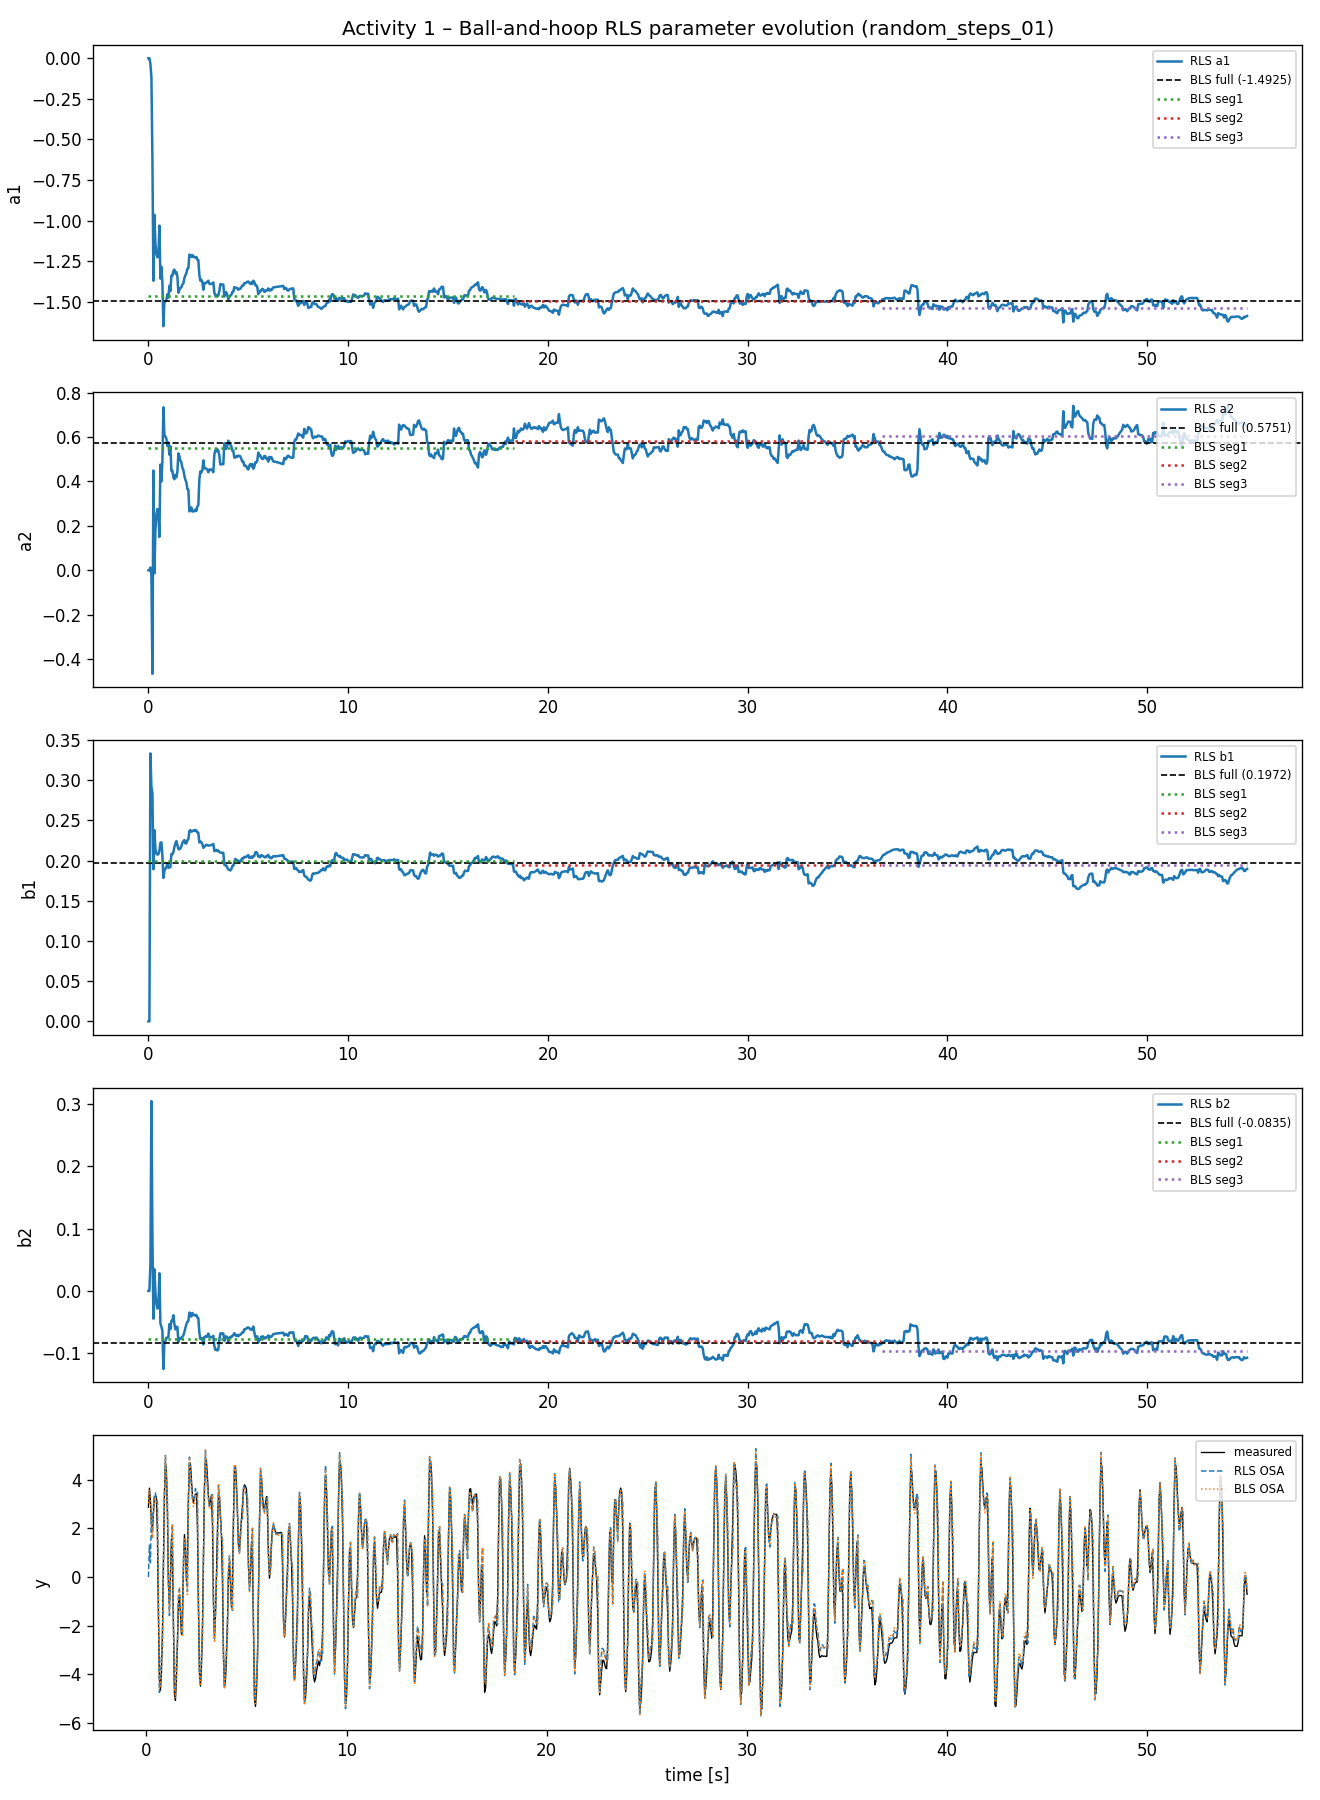

In [1]:
def activity1():
    """RLS on ball-and-hoop data; compare final estimate to BLS on segments."""
    try:
        import bab_datasets as nod
    except ImportError:
        print("[Activity 1] SKIPPED – bab_datasets not installed.\n"
              "  pip install git+https://github.com/helonayala/bab_datasets.git")
        return

    # Use the random_steps_01 dataset (uniform step excitation)
    EXPERIMENT = "random_steps_01"
    RESAMPLE_FACTOR = 50
    N_A, N_B = 2, 2
    LAM = 0.98

    print("=" * 70)
    print("ACTIVITY 1 - Ball-and-hoop RLS  (experiment: %s)" % EXPERIMENT)
    print("=" * 70)

    data = nod.load_experiment(
        EXPERIMENT,
        preprocess=True,
        plot=False,
        end_idx=None,
        resample_factor=RESAMPLE_FACTOR,
        zoom_last_n=None,
        y_dot_method="savgol",
    )
    u = np.asarray(data.u, dtype=float).ravel()
    y = np.asarray(data.y, dtype=float).ravel()
    ts = float(data.sampling_time)
    n = u.size
    print(f"Samples: {n},  Ts = {ts:.4f} s")

    # --- RLS on the full record -------------------------------------------
    th_hist, yhat_rls, _ = rls(u, y, N_A, N_B, lam=LAM)
    th_rls_final = th_hist[-1]
    print(f"\nRLS final theta  (lambda={LAM}): {th_rls_final}")

    # --- BLS on the full record (baseline) --------------------------------
    Phi_full, Y_full = regression_matrix(u, y, N_A, N_B)
    th_bls_full, *_ = np.linalg.lstsq(Phi_full, Y_full, rcond=None)
    print(f"BLS full theta               : {th_bls_full}")

    # --- BLS on three equal segments (mimics batch-per-segment) -----------
    seg_size = n // 3
    print("\nBLS on three equal segments:")
    seg_thetas = []
    for seg_idx in range(3):
        i0 = seg_idx * seg_size
        i1 = i0 + seg_size if seg_idx < 2 else n
        Phi_s, Y_s = regression_matrix(u[i0:i1], y[i0:i1], N_A, N_B)
        th_s, *_ = np.linalg.lstsq(Phi_s, Y_s, rcond=None)
        seg_thetas.append(th_s)
        print(f"  segment {seg_idx + 1} (k={i0}..{i1-1}): {th_s}")

    # --- OSA metrics -------------------------------------------------------
    p = max(N_A, N_B)
    Y_valid = Y_full                       # shape (n-p,)
    yhat_rls_valid = yhat_rls[p:]
    yhat_bls_valid = Phi_full @ th_bls_full
    rmse_rls, r2_rls = evaluate(Y_valid, yhat_rls_valid)
    rmse_bls, r2_bls = evaluate(Y_valid, yhat_bls_valid)
    print(f"\n{'method':<18}{'RMSE':>14}{'R2':>12}")
    print(f"{'RLS (full)':<18}{rmse_rls:>14.4e}{r2_rls:>12.4f}")
    print(f"{'BLS (full)':<18}{rmse_bls:>14.4e}{r2_bls:>12.4f}")

    # --- Figure: parameter evolution + OSA comparison ---------------------
    t = np.arange(n) * ts
    param_labels = [f"a{i+1}" for i in range(N_A)] + [f"b{i+1}" for i in range(N_B)]

    fig, axes = plt.subplots(N_A + N_B + 1, 1,
                             figsize=(11, 3 * (N_A + N_B + 1)),
                             sharex=False)
    for j, lbl in enumerate(param_labels):
        axes[j].plot(t, th_hist[:, j], label=f"RLS {lbl}")
        axes[j].axhline(th_bls_full[j], color="k", ls="--", lw=1,
                        label=f"BLS full ({th_bls_full[j]:.4f})")
        for seg_idx, th_s in enumerate(seg_thetas):
            i0 = seg_idx * seg_size
            i1 = (i0 + seg_size) if seg_idx < 2 else n
            axes[j].hlines(th_s[j], t[i0], t[i1 - 1],
                           colors=f"C{seg_idx + 2}", linestyles=":",
                           label=f"BLS seg{seg_idx + 1}")
        axes[j].set_ylabel(lbl)
        axes[j].legend(loc="upper right", fontsize=7)

    ax_y = axes[-1]
    t_valid = t[p:]
    ax_y.plot(t_valid, Y_valid, "k", lw=0.8, label="measured")
    ax_y.plot(t_valid, yhat_rls_valid, "--", lw=0.9, label="RLS OSA")
    ax_y.plot(t_valid, yhat_bls_valid, ":", lw=0.9, label="BLS OSA")
    ax_y.set_ylabel("y")
    ax_y.set_xlabel("time [s]")
    ax_y.legend(loc="upper right", fontsize=7)
    axes[0].set_title(f"Activity 1 – Ball-and-hoop RLS parameter evolution ({EXPERIMENT})")
    fig.tight_layout()
    fname = os.path.join(HERE, "act1_bah_rls.png")
    fig.savefig(fname, dpi=120)
    print(f"\nSaved: {fname}")

## Activity 2 - MIMO Aluminium-plate benchmark (SISO slice, RLS)

In [ ]:
def _load_mimo_al_data(data_dir,
                       fname=_MIMO_FILE,
                       iu=_MIMO_IU,
                       iy=_MIMO_IY,
                       experiment=_MIMO_EXPERIMENT):
    """Load one SISO slice of the MIMO Aluminium-plate benchmark.

    The .mat file stores a nested MATLAB struct `data` with fields
    u, y, r, Ts, N, ExcitedHarm.  The forces (u) and accelerations (y) are
    4-D arrays shaped (nu, M, 1, N): nu=2 inputs, M=2 independent
    experiments, N time samples (concatenated periods).  We pick a single
    input/output channel and a single experiment, undo the charge-amplifier
    gains, and return flat 1-D signals for the ARX/RLS pipeline.

    Parameters
    ----------
    fname      : .mat file inside data_dir
    iu, iy     : 0-based input / output channel indices (each 0 or 1)
    experiment : 0 = identification realisation, 1 = validation realisation

    Returns (u, y, ts) or raises FileNotFoundError with instructions.
    """
    path = os.path.join(data_dir, fname)
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"MIMO Al-plate data not found at '{path}'.\n"
            f"  Place the benchmark .mat files in '{data_dir}' and set\n"
            "  MIMO_AL_DATA_DIR / _MIMO_FILE in this script accordingly."
        )

    from scipy.io import loadmat
    mat = loadmat(path, struct_as_record=False, squeeze_me=False)
    data = mat["data"][0, 0]

    # u, y : (nu, M, 1, N) – select channel (iu/iy) and experiment, undo gains
    u = np.asarray(data.u[iu, experiment, 0, :], dtype=float) / _MIMO_SCALE_IN[iu]
    y = np.asarray(data.y[iy, experiment, 0, :], dtype=float) / _MIMO_SCALE_OUT[iy]
    ts = float(np.ravel(data.Ts)[0])

    return u.ravel(), y.ravel(), ts

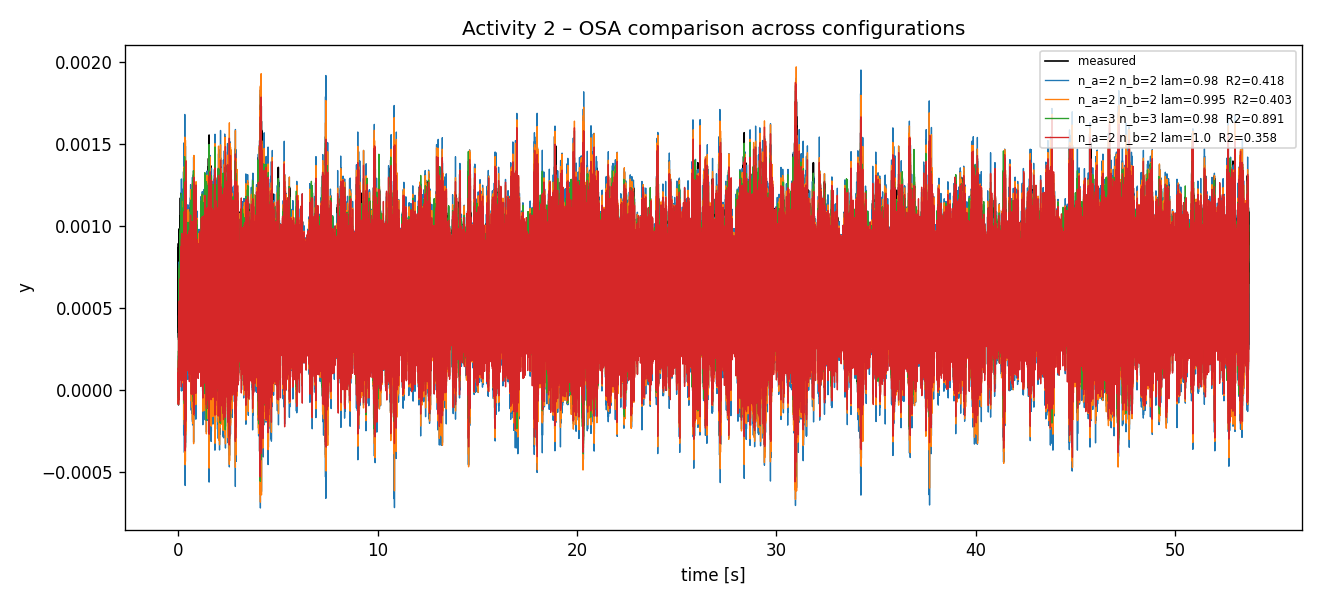

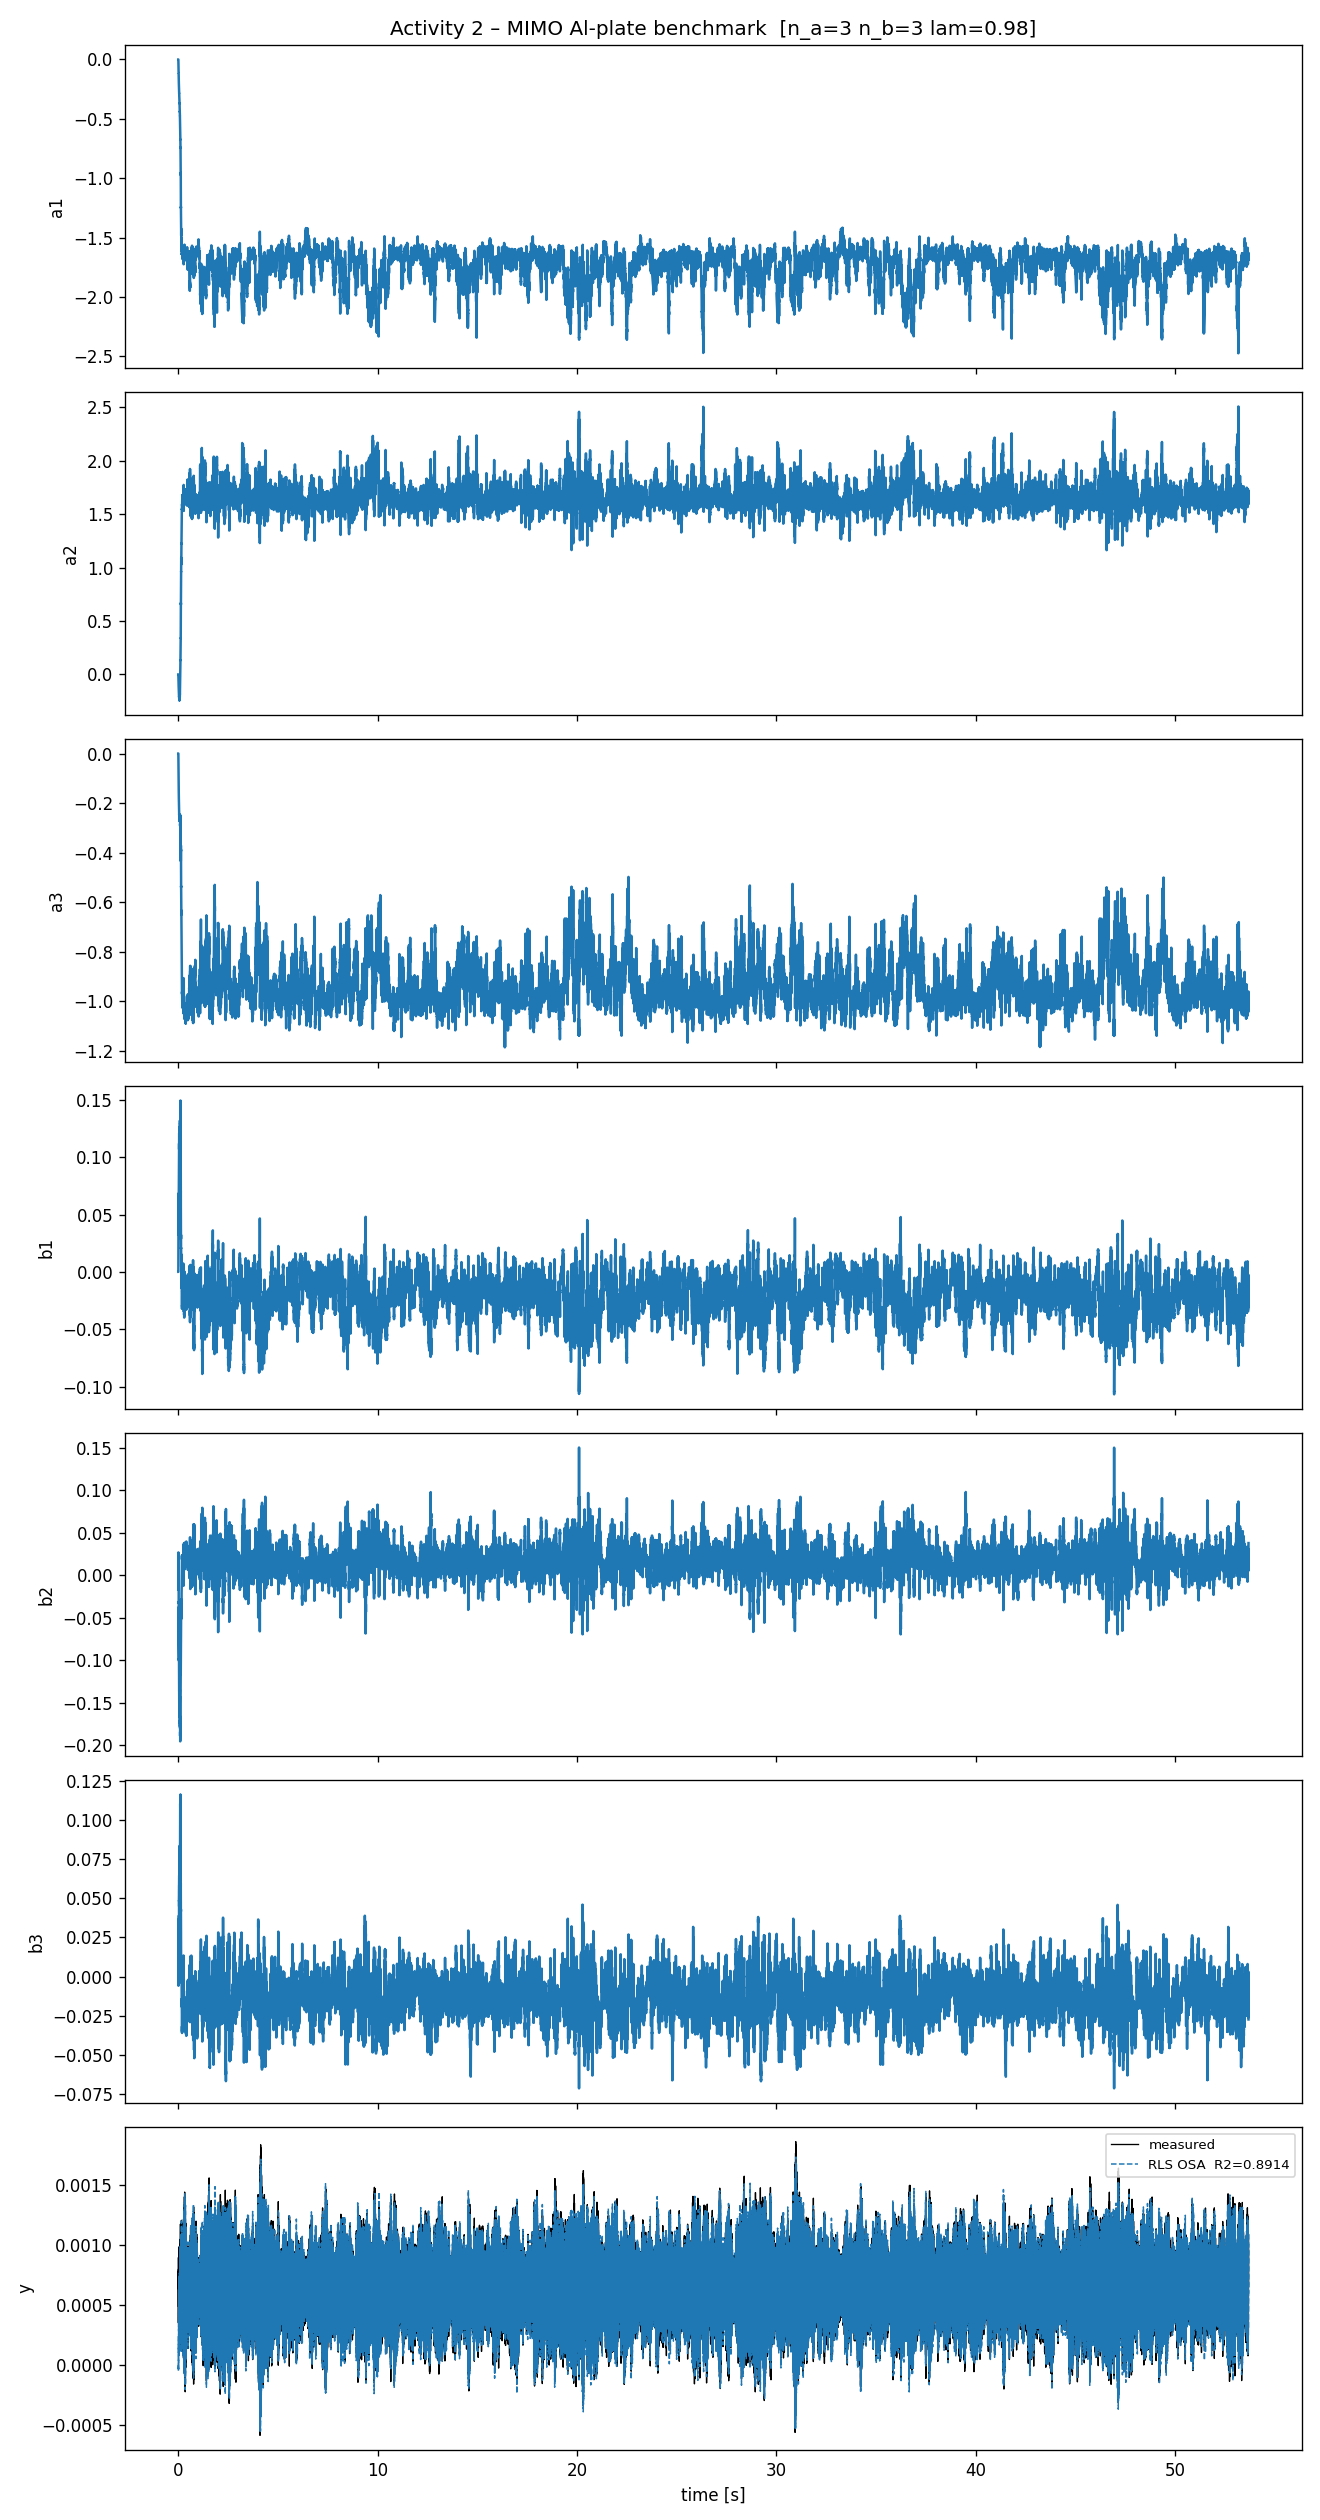

In [2]:
def activity2():
    """MIMO Al-plate benchmark: RLS on one SISO input/output slice."""
    print("=" * 70)
    print("ACTIVITY 2 - MIMO Aluminium-plate benchmark (SISO slice, RLS)")
    print("=" * 70)

    try:
        u, y, ts = _load_mimo_al_data(MIMO_AL_DATA_DIR)
    except FileNotFoundError as exc:
        print(f"[Activity 2] SKIPPED – {exc}")
        return

    n = u.size
    print(f"File: {_MIMO_FILE}  |  input u[{_MIMO_IU}] -> output y[{_MIMO_IY}]  "
          f"(experiment {_MIMO_EXPERIMENT})")
    print(f"Samples: {n},  Ts = {ts:.6f} s  ({n * ts:.1f} s total, "
          f"fs = {1.0/ts:.1f} Hz)")

    # Candidate ARX orders / forgetting factors for the plate dynamics
    experiments = [
        dict(label="n_a=2 n_b=2 lam=0.98", n_a=2, n_b=2, lam=0.98),
        dict(label="n_a=2 n_b=2 lam=0.995", n_a=2, n_b=2, lam=0.995),
        dict(label="n_a=3 n_b=3 lam=0.98",  n_a=3, n_b=3, lam=0.98),
        dict(label="n_a=2 n_b=2 lam=1.0",   n_a=2, n_b=2, lam=1.0),
    ]

    results = []
    for cfg in experiments:
        na, nb, lam = cfg["n_a"], cfg["n_b"], cfg["lam"]
        th_hist, yhat, _ = rls(u, y, na, nb, lam=lam)
        p = max(na, nb)
        _, Y_val = regression_matrix(u, y, na, nb)
        yhat_val = yhat[p:]
        rmse, r2 = evaluate(Y_val, yhat_val)
        results.append(dict(**cfg, th_hist=th_hist, yhat=yhat,
                            rmse=rmse, r2=r2, p=p))
        print(f"  {cfg['label']:<30}  RMSE={rmse:.4e}  R2={r2:.4f}")

    # Summary table
    print(f"\n{'Configuration':<30}{'RMSE':>14}{'R2':>10}")
    print("-" * 55)
    for r in results:
        print(f"{r['label']:<30}{r['rmse']:>14.4e}{r['r2']:>10.4f}")

    # Best configuration
    best = min(results, key=lambda r: r["rmse"])
    print(f"\nBest configuration (lowest RMSE): {best['label']}")

    # Figure: OSA prediction and parameter evolution for best config
    na, nb, p = best["n_a"], best["n_b"], best["p"]
    th_hist = best["th_hist"]
    yhat = best["yhat"]
    _, Y_val = regression_matrix(u, y, na, nb)
    t = np.arange(n) * ts
    t_val = t[p:]
    n_params = na + nb
    param_labels = [f"a{i+1}" for i in range(na)] + [f"b{i+1}" for i in range(nb)]

    fig, axes = plt.subplots(n_params + 1, 1,
                             figsize=(11, 3 * (n_params + 1)),
                             sharex=True)
    for j, lbl in enumerate(param_labels):
        axes[j].plot(t, th_hist[:, j])
        axes[j].set_ylabel(lbl)
    axes[-1].plot(t_val, Y_val, "k", lw=0.8, label="measured")
    axes[-1].plot(t_val, yhat[p:], "--", lw=0.9,
                  label=f"RLS OSA  R2={best['r2']:.4f}")
    axes[-1].set_ylabel("y")
    axes[-1].set_xlabel("time [s]")
    axes[-1].legend(fontsize=8)
    axes[0].set_title(f"Activity 2 – MIMO Al-plate benchmark  [{best['label']}]")
    fig.tight_layout()
    fname = os.path.join(HERE, "act2_mimo_al_rls.png")
    fig.savefig(fname, dpi=120)
    print(f"Saved: {fname}")

    # Comparison figure: all configs (OSA output only)
    fig2, ax2 = plt.subplots(figsize=(11, 5))
    ax2.plot(t_val, Y_val, "k", lw=1.0, label="measured")
    for r in results:
        ax2.plot(t[r["p"]:], r["yhat"][r["p"]:], lw=0.8,
                 label=f"{r['label']}  R2={r['r2']:.3f}")
    ax2.set_xlabel("time [s]")
    ax2.set_ylabel("y")
    ax2.set_title("Activity 2 – OSA comparison across configurations")
    ax2.legend(fontsize=7)
    fig2.tight_layout()
    fname2 = os.path.join(HERE, "act2_mimo_al_comparison.png")
    fig2.savefig(fname2, dpi=120)
    print(f"Saved: {fname2}")

## Activity 3 - Wind turbine blade crack detection

In [ ]:
# Zenodo record 3229743 – 0 °C cases
_ZENODO_URL_R = "https://zenodo.org/records/3229743/files/Case_R_(+00).zip?download=1"
_ZENODO_URL_L = "https://zenodo.org/records/3229743/files/Case_L_(+00).zip?download=1"


# Which excitation to identify on.  Each case folder holds many .lvm files
# (white_noise_1..20, sine_sweep, temperature_compensation); the RLS pipeline
# assumes broadband white-noise excitation, so we deliberately select a
# white-noise record rather than whatever os.walk happens to list first.
_LVM_PREFERRED = "white_noise_1.lvm"

In [ ]:
def _pick_lvm(extract_dir):
    """Deterministically choose one .lvm under extract_dir.

    Prefers `_LVM_PREFERRED`, then any `white_noise_*.lvm` (sorted), and only
    falls back to any other .lvm (sorted) if no white-noise file exists.
    Returns an absolute path or None.
    """
    all_lvm = []
    for root, _, files in os.walk(extract_dir):
        for f in files:
            if f.lower().endswith(".lvm"):
                all_lvm.append(os.path.join(root, f))
    if not all_lvm:
        return None
    all_lvm.sort()

    exact = [p for p in all_lvm if os.path.basename(p) == _LVM_PREFERRED]
    if exact:
        return exact[0]
    white = [p for p in all_lvm if os.path.basename(p).lower().startswith("white_noise")]
    if white:
        return white[0]
    return all_lvm[0]

In [ ]:
def _ensure_wind_data(data_dir):
    """Locate the wind turbine .lvm files, extracting/downloading if needed.

    Uses any zip already present in data_dir (the Zenodo files keep their
    original names, e.g. 'Case_R_(+00).zip'); only downloads when missing.

    Returns (lvm_path_R, lvm_path_L) absolute paths to the .lvm files.
    """
    import urllib.request
    import zipfile

    os.makedirs(data_dir, exist_ok=True)

    results = []
    for condition, url, zip_name, folder_name in [
        ("R", _ZENODO_URL_R, "Case_R_(+00).zip", "Case_R_(+00)"),
        ("L", _ZENODO_URL_L, "Case_L_(+00).zip", "Case_L_(+00)"),
    ]:
        zip_path = os.path.join(data_dir, zip_name)
        extract_dir = os.path.join(data_dir, folder_name)

        # 1. Already extracted?
        lvm_path = _pick_lvm(extract_dir) if os.path.isdir(extract_dir) else None

        if lvm_path is None:
            # 2. Download the ZIP only if it is not already on disk.
            if not os.path.isfile(zip_path):
                print(f"  Downloading Case {condition} from Zenodo (~500 MB – 1.7 GB)...")
                urllib.request.urlretrieve(url, zip_path)
                print(f"  Download complete: {zip_path}")
            # 3. Extract and search again.
            print(f"  Extracting {zip_name} ...")
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(data_dir)
            lvm_path = _pick_lvm(extract_dir)

        if lvm_path is None:
            raise FileNotFoundError(
                f"Could not find a .lvm file under '{extract_dir}' "
                f"for Case {condition}."
            )
        print(f"  Case {condition}: using {os.path.relpath(lvm_path, data_dir)}")
        results.append(lvm_path)

    return results[0], results[1]

In [ ]:
def _load_lvm(path):
    """Load a LabVIEW .lvm file and return (u, y, fs).

    Column layout (0-based):
      0        : time
      1 – 8    : accelerometer channels Ch1-Ch8
      13       : force excitation signal

    Uses the lvm_read package (pip install lvm_read).
    """
    try:
        import lvm_read
    except ImportError as exc:
        # Raise ImportError (not SystemExit) so activity3's `except Exception`
        # can skip the activity gracefully instead of killing the whole script.
        raise ImportError(
            "The 'lvm_read' package is required for Activity 3.\n"
            "Install it with:  pip install lvm_read"
        ) from exc

    lvm = lvm_read.read(path)
    data = np.asarray(lvm[0]["data"], dtype=float)

    u = data[:, _LVM_COL_FORCE]
    y = data[:, _LVM_COL_ACCEL]

    # Sampling frequency from the X_Increment field (time step)
    dt = float(lvm[0].get("Delta_X", [1.0 / 1000.0])[0])
    fs = 1.0 / dt

    return u, y, fs

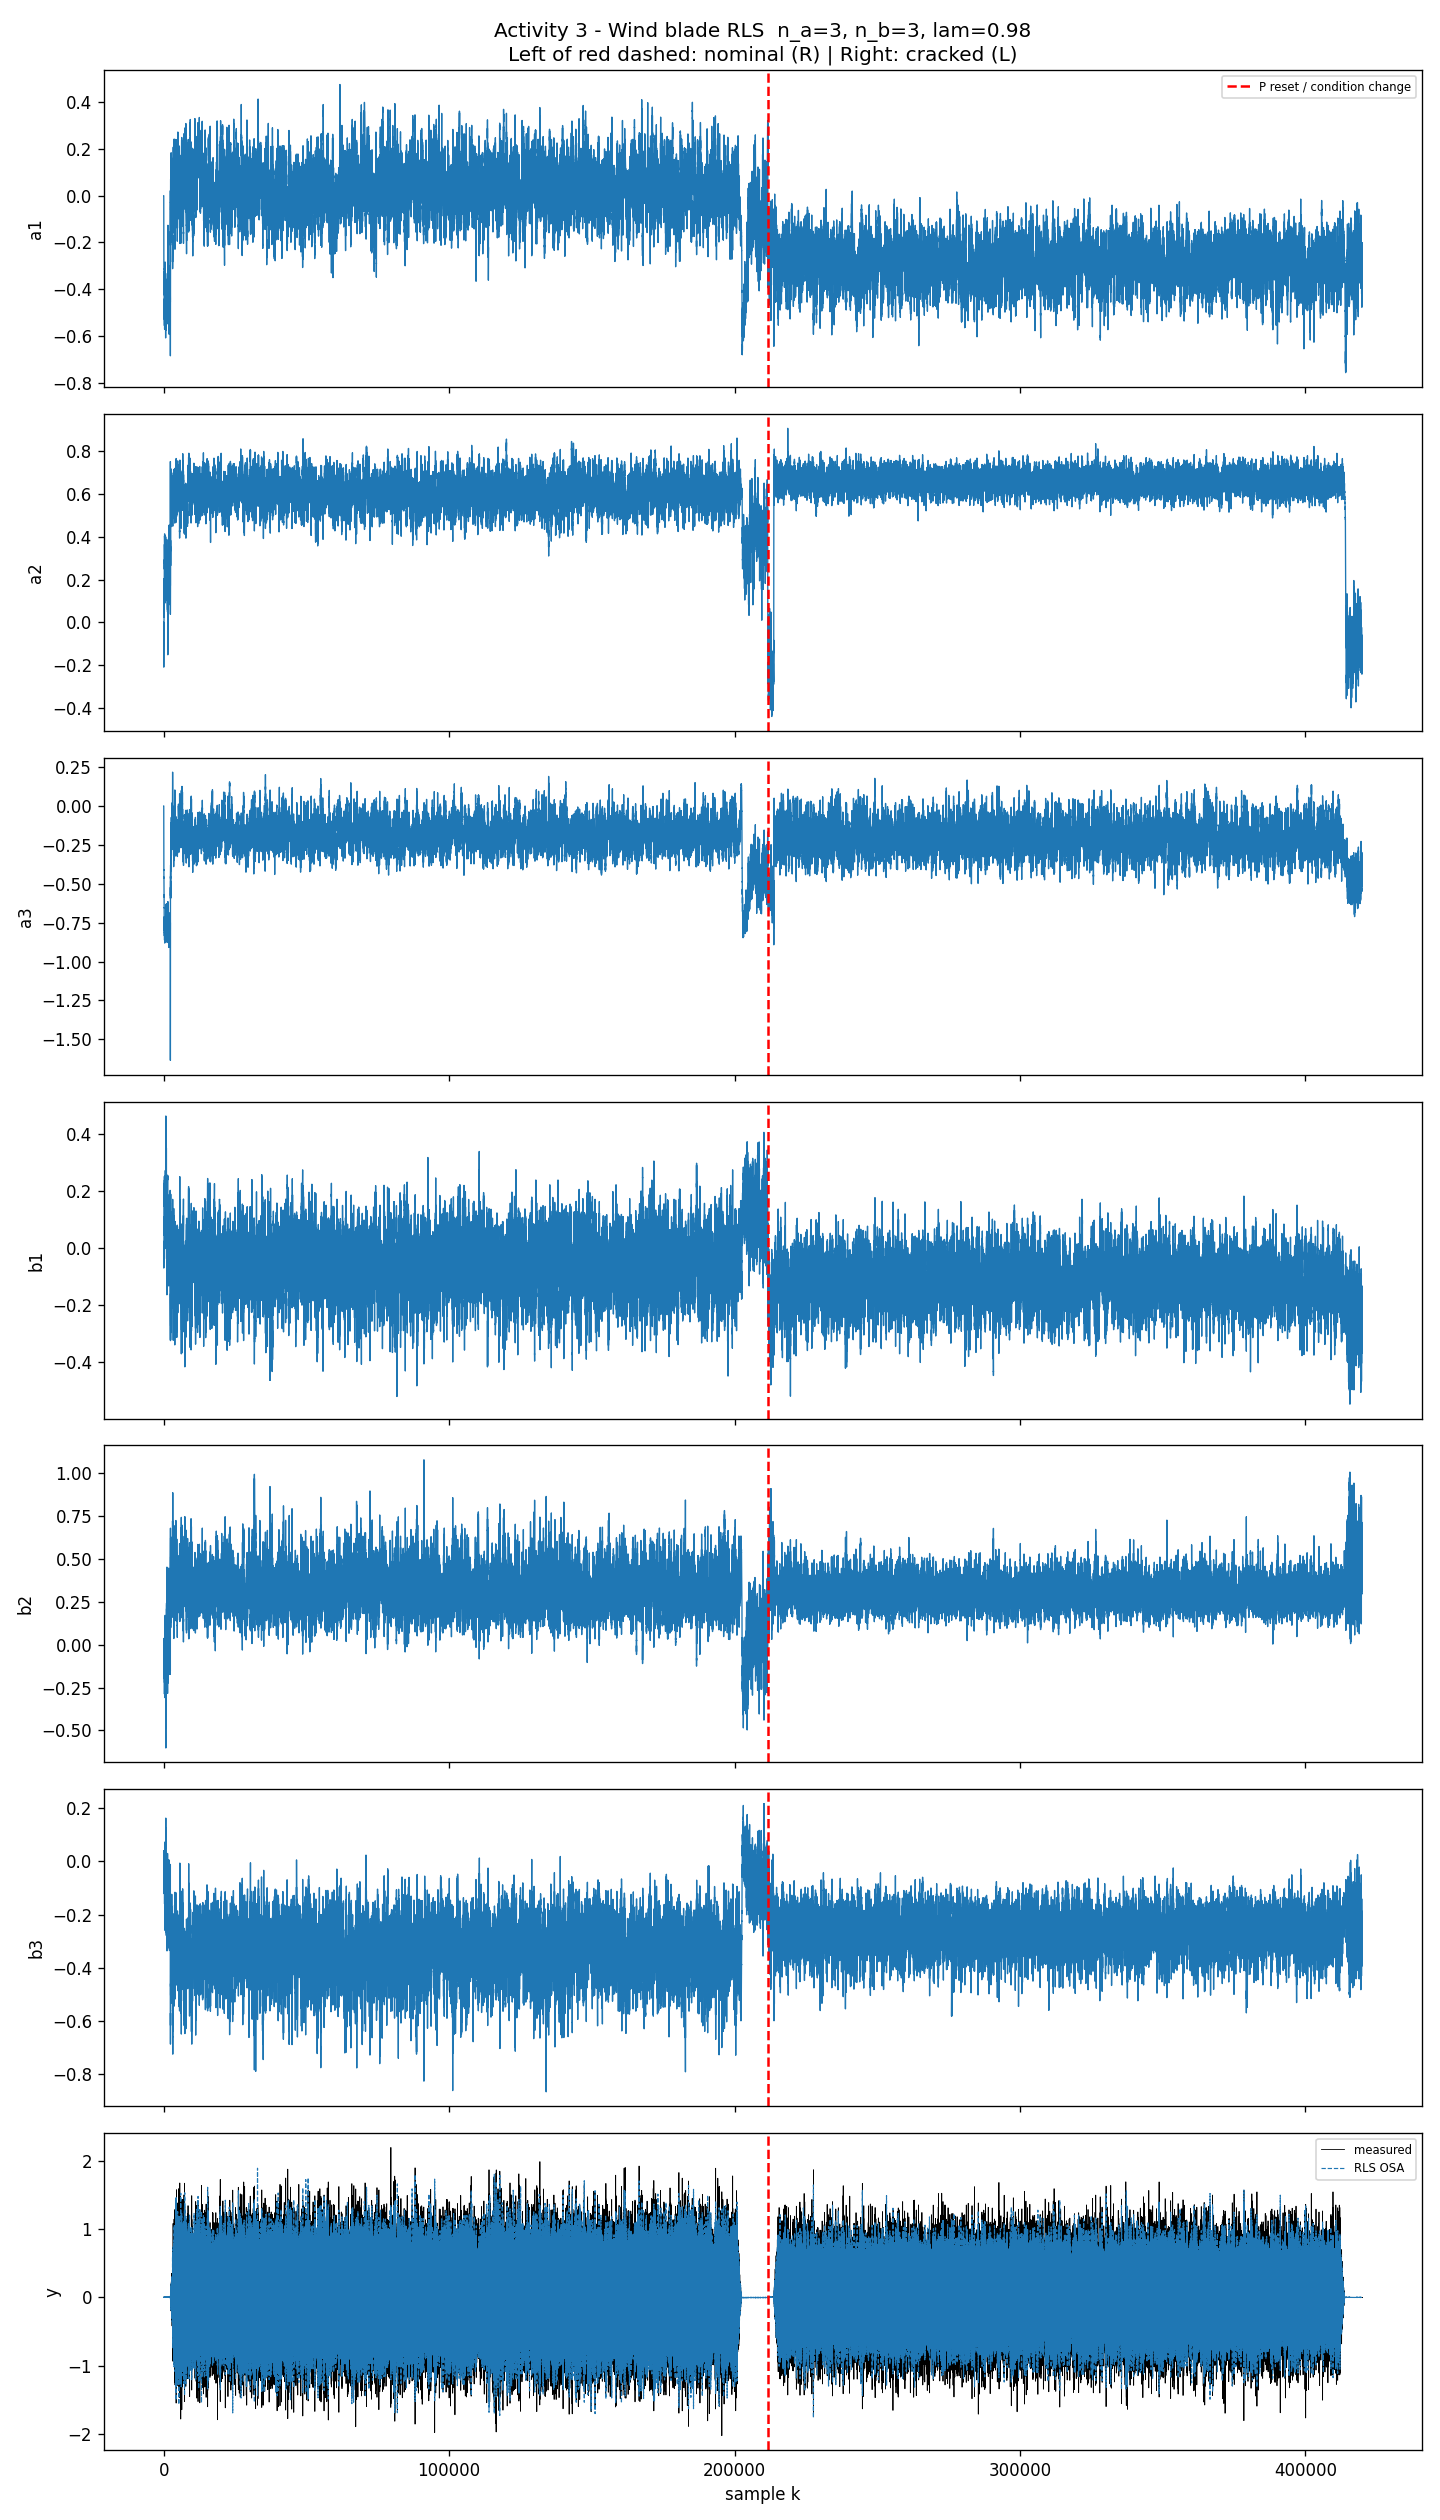

In [3]:
def activity3():
    """Wind turbine blade crack detection via RLS with covariance resetting."""
    print("=" * 70)
    print("ACTIVITY 3 - Wind turbine blade crack detection (RLS)")
    print("=" * 70)

    try:
        lvm_R, lvm_L = _ensure_wind_data(WIND_DATA_DIR)
    except Exception as exc:
        print(f"[Activity 3] SKIPPED – could not obtain data: {exc}")
        return

    try:
        u_nom, y_nom, fs = _load_lvm(lvm_R)
        u_crk, y_crk, _  = _load_lvm(lvm_L)
    except Exception as exc:
        print(f"[Activity 3] SKIPPED – could not load .lvm files: {exc}")
        return

    print(f"Nominal dataset : {u_nom.size} samples")
    print(f"Cracked dataset : {u_crk.size} samples")

    # --- Step 1: determine model orders from nominal dataset via BLS sweep --
    print("\nModel-order sweep on nominal data (BLS, free-run R2):")
    n_nom = u_nom.size
    split = n_nom // 2
    u_n_tr, y_n_tr = u_nom[:split], y_nom[:split]
    u_n_te, y_n_te = u_nom[split:], y_nom[split:]

    candidates = [(1, 1), (2, 1), (1, 2), (2, 2), (3, 2), (2, 3), (3, 3)]
    best_r2, best_na, best_nb = -np.inf, 2, 2
    for na, nb in candidates:
        try:
            Phi_tr, Y_tr = regression_matrix(u_n_tr, y_n_tr, na, nb)
            th_b, *_ = np.linalg.lstsq(Phi_tr, Y_tr, rcond=None)
            _, Y_te = regression_matrix(u_n_te, y_n_te, na, nb)
            y_fr = free_run(th_b, u_n_te, y_n_te, na, nb)
            _, r2 = evaluate(Y_te, y_fr)
            marker = " <-- best" if r2 > best_r2 else ""
            if r2 > best_r2:
                best_r2, best_na, best_nb = r2, na, nb
            print(f"  n_a={na}, n_b={nb}  free-run R2={r2:.4f}{marker}")
        except Exception as exc:
            print(f"  n_a={na}, n_b={nb}  ERROR: {exc}")

    N_A, N_B = best_na, best_nb
    print(f"\nSelected orders: n_a={N_A}, n_b={N_B}")

    # --- Step 2: concatenate datasets and run RLS with covariance reset -----
    u_cat = np.concatenate([u_nom, u_crk])
    y_cat = np.concatenate([y_nom, y_crk])
    reset_at = [u_nom.size]   # reset P at the join between conditions

    LAM = 0.98
    th_hist, yhat, _ = rls_reset(u_cat, y_cat, N_A, N_B,
                                  lam=LAM, reset_indices=reset_at)

    n_cat = u_cat.size
    p = max(N_A, N_B)
    _, Y_cat = regression_matrix(u_cat, y_cat, N_A, N_B)
    rmse_all, r2_all = evaluate(Y_cat, yhat[p:])
    print(f"\nRLS OSA on concatenated data:  RMSE={rmse_all:.4e}  R2={r2_all:.4f}")

    # --- Step 3: per-condition OSA metrics ---------------------------------
    n_nom_p = u_nom.size - p
    yhat_nom_seg = yhat[p: u_nom.size]
    yhat_crk_seg = yhat[u_nom.size: u_nom.size + (u_crk.size - p)]
    _, Y_nom_seg = regression_matrix(u_nom, y_nom, N_A, N_B)
    _, Y_crk_seg = regression_matrix(u_crk, y_crk, N_A, N_B)
    rmse_n, r2_n = evaluate(Y_nom_seg, yhat[p: u_nom.size])
    rmse_c, r2_c = evaluate(Y_crk_seg, yhat[u_nom.size: u_nom.size + Y_crk_seg.size])
    print(f"\n{'condition':<14}{'RMSE':>14}{'R2':>10}")
    print(f"{'nominal (R)':<14}{rmse_n:>14.4e}{r2_n:>10.4f}")
    print(f"{'cracked (L)':<14}{rmse_c:>14.4e}{r2_c:>10.4f}")

    # --- Figure: parameter trajectory over concatenated sequence -----------
    n_params = N_A + N_B
    param_labels = [f"a{i+1}" for i in range(N_A)] + [f"b{i+1}" for i in range(N_B)]
    k_axis = np.arange(n_cat)

    fig, axes = plt.subplots(n_params + 1, 1,
                             figsize=(12, 3 * (n_params + 1)),
                             sharex=True)
    for j, lbl in enumerate(param_labels):
        axes[j].plot(k_axis, th_hist[:, j], lw=0.8)
        axes[j].axvline(u_nom.size, color="r", lw=1.5, ls="--",
                        label="P reset / condition change")
        axes[j].set_ylabel(lbl)
        if j == 0:
            axes[j].legend(fontsize=7)

    axes[-1].plot(k_axis[p:], Y_cat, "k", lw=0.5, label="measured")
    axes[-1].plot(k_axis[p:], yhat[p:], "--", lw=0.7, label="RLS OSA")
    axes[-1].axvline(u_nom.size, color="r", lw=1.5, ls="--")
    axes[-1].set_ylabel("y")
    axes[-1].set_xlabel("sample k")
    axes[-1].legend(fontsize=7)

    axes[0].set_title(
        f"Activity 3 - Wind blade RLS  n_a={N_A}, n_b={N_B}, lam={LAM}\n"
        f"Left of red dashed: nominal (R) | Right: cracked (L)"
    )
    fig.tight_layout()
    fname = os.path.join(HERE, "act3_wind_rls.png")
    fig.savefig(fname, dpi=120)
    print(f"\nSaved: {fname}")

## Driver

In [ ]:
np.set_printoptions(precision=6, suppress=True)
activity1()
print()
activity2()
print()
activity3()